--- Pemilih Metrik Lohong Hitam (Berdasarkan Framework Tesis) ---
  1: Schwarzschild (Standard)
  2: Reissner-Nordström (Bercas Q)
  3: Kottler / S-deSitter (Pemalar Lambda)
  4: Bardeen (Regular / Tanpa Singularity)
  5: Schwarzschild-Anti-de Sitter (SAdS)
  6: Hayward (Regular / Teras Quantum)
  7: Kiselev (Quintessence Fluid)
  8: Mannheim-Kazanas (Conformal Gravity)

Metrik yang dipilih: Schwarzschild (Standard)

--- Lapse Function f(r) ---


Eq(lapse, -2*M/r + 1)

lapse = - \frac{2 M}{r} + 1

--- 1. LAGRANGIAN (L) ---


Eq(lagrangian, phi_dot**2*r**2/2 + r_dot**2/(2*(-2*M/r + 1)) + t_dot**2*(2*M/r - 1)/2)

lagrangian = \frac{\phi_{dot}^{2} r^{2}}{2} + \frac{r_{dot}^{2}}{2 \left(- \frac{2 M}{r} + 1\right)} + \frac{t_{dot}^{2} \left(\frac{2 M}{r} - 1\right)}{2}

--- 2. CONSTANTS OF MOTION ---


...

b = 5.19615242270663

--- 6. ORBITAL EQUATION (dr/dphi)² ---


Eq(dr_dphi_square, 2*M*r - r**2 + r**4/b**2)

dr_{dphi square} = 2 M r - r^{2} + \frac{r^{4}}{b^{2}}

--- 7. ODE FOR SOLVER (dr/dphi) ---


Eq(dr_dphi, sqrt(2*M*r - r**2 + r**4/b**2))

dr_{dphi} = \sqrt{2 M r - r^{2} + \frac{r^{4}}{b^{2}}}

Firing 1000 photons...
Saved null_geodesics.png


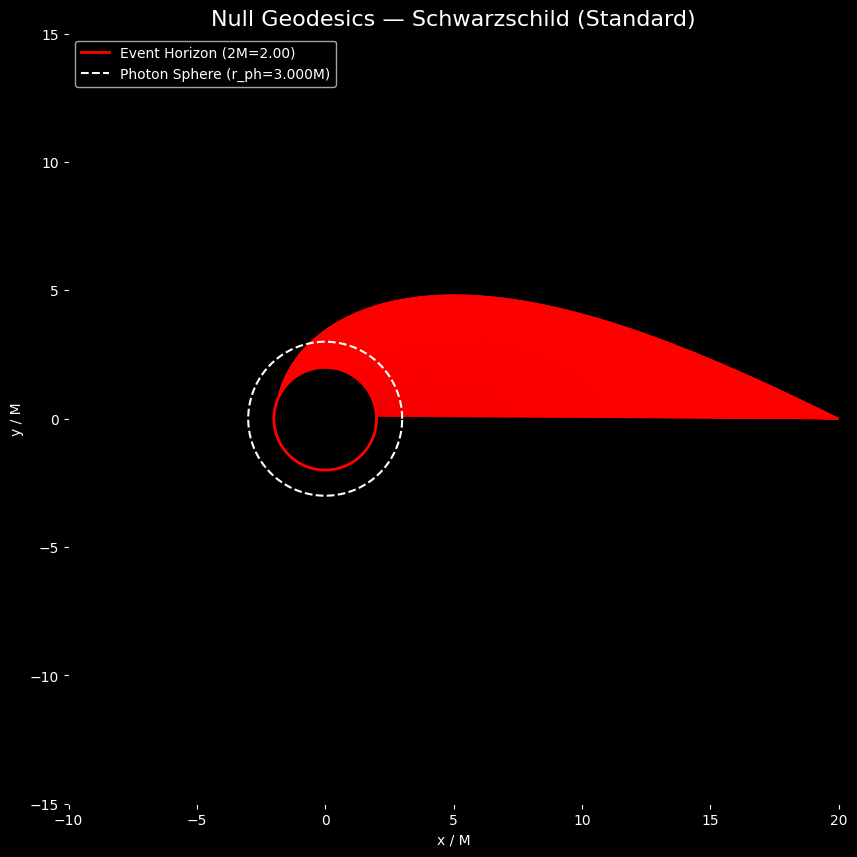

Rendered 640000 pixels.
Saved bh_shadow.png


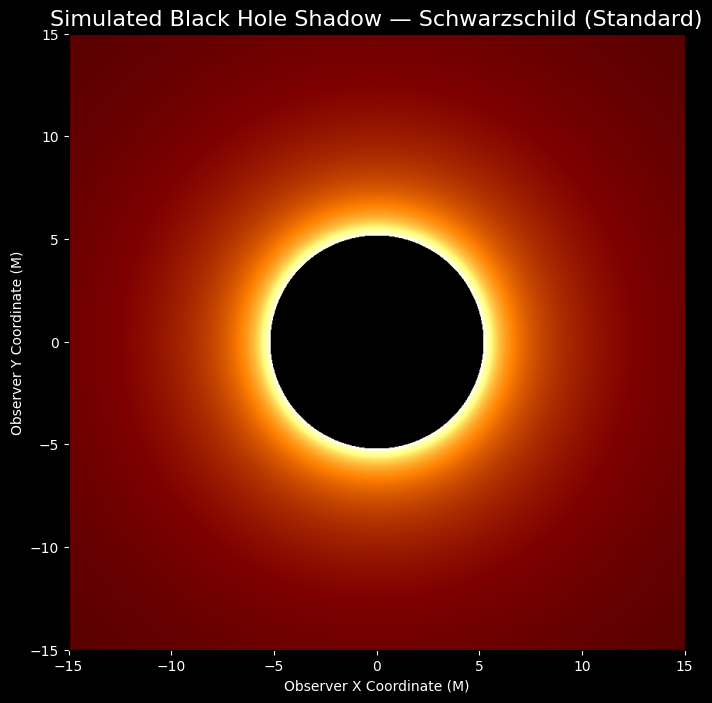

Saved veff_plot.png


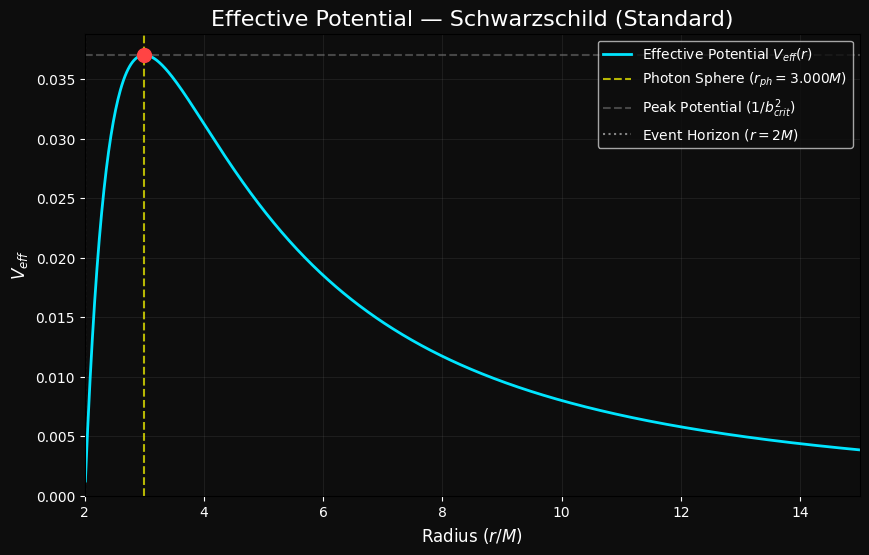

In [1]:
import sympy as sp
from sympy import *
import numpy as np
import matplotlib.pyplot as plt

# FIX #7: Proper display/latex helpers that work both in Jupyter and plain Python
try:
    from IPython.display import display as ipy_display
    _in_jupyter = True
except ImportError:
    _in_jupyter = False

def display(expr):
    if _in_jupyter:
        ipy_display(expr)
    else:
        print(expr)

def print_latex(expr):
    print(sp.latex(expr))


def automated_black_hole_engine():
    # =====================================================================
    # 1. SETUP SYMBOLS  (natural units: G = c = 1)
    # =====================================================================
    # FIX #1/#3: All SymPy symbols are defined here and NEVER reassigned.
    # Numeric values live in separate Python variables (M_val, r_arr, etc.)
    r_sym, M_sym, b_sym = sp.symbols('r M b', positive=True, real=True)
    E_sym, L_sym        = sp.symbols('E L',   positive=True, real=True)
    A_sym               = sp.symbols('A')
    v_sym               = sp.symbols('v')
    Q_sym               = sp.symbols('Q',  positive=True, real=True)
    g_sym               = sp.symbols('g')
    l_sym               = sp.symbols('l')
    Ads_sym             = sp.symbols('Ads')
    a_sym               = sp.symbols('a')
    w_sym               = sp.symbols('w')
    y_sym               = sp.symbols('y')
    k_sym               = sp.symbols('k')

    t_dot, r_dot, phi_dot       = sp.symbols('t_dot r_dot phi_dot', real=True)
    dr_dphi_sym                 = sp.symbols('dr_dphi')
    lagrangian_sym              = sp.symbols('lagrangian')
    r_dot_square_sym            = sp.symbols('r_dot_square')
    dr_dphi_square_sym          = sp.symbols('dr_dphi_square')
    lapse_sym                   = sp.symbols('lapse')

    # =====================================================================
    # 2. METRIC SELECTION
    # =====================================================================
    print("--- Pemilih Metrik Lohong Hitam (Berdasarkan Framework Tesis) ---")
    metrics = {
        "1": "Schwarzschild (Standard)",
        "2": "Reissner-Nordström (Bercas Q)",
        "3": "Kottler / S-deSitter (Pemalar Lambda)",
        "4": "Bardeen (Regular / Tanpa Singularity)",
        "5": "Schwarzschild-Anti-de Sitter (SAdS)",
        "6": "Hayward (Regular / Teras Quantum)",
        "7": "Kiselev (Quintessence Fluid)",
        "8": "Mannheim-Kazanas (Conformal Gravity)"
    }

    for key, name in metrics.items():
        print(f"  {key}: {name}")

    choice = input("\nPilih nombor metrik (1-8): ").strip()
    if choice not in metrics:
        print("Pilihan tidak sah.")
        return
    print(f"\nMetrik yang dipilih: {metrics[choice]}\n")

    # Numeric parameter dict — uses SymPy symbols as keys, floats as values
    params = {M_sym: 1.0}

    if choice == '1':
        f_r = 1 - 2*M_sym/r_sym
    elif choice == '2':
        f_r = 1 - 2*M_sym/r_sym + Q_sym**2/r_sym**2
        params[Q_sym] = 0.5
    elif choice == '3':
        f_r = 1 - 2*M_sym/r_sym - (A_sym * r_sym**2 / 3)
        params[A_sym] = 0.01
    elif choice == '4':
        f_r = 1 - (2*M_sym * r_sym**2) / (r_sym**2 + g_sym**2)**sp.Rational(3, 2)
        params[g_sym] = 0.6
    elif choice == '5':
        f_r = 1 - 2*M_sym/r_sym + r_sym**2/Ads_sym**2
        params[Ads_sym] = 10.0
    elif choice == '6':
        f_r = 1 - (2*M_sym * r_sym**2) / (r_sym**3 + 2*M_sym*l_sym**2)
        params[l_sym] = 0.5
    elif choice == '7':
        f_r = 1 - 2*M_sym/r_sym - a_sym/r_sym**(3*w_sym + 1)
        params[a_sym] = 0.05
        params[w_sym] = sp.Rational(-2, 3)
    elif choice == '8':
        f_r = 1 - 2*M_sym/r_sym + y_sym*r_sym - k_sym*r_sym**2
        params[y_sym] = 0.01
        params[k_sym] = 0.001

    print("--- Lapse Function f(r) ---")
    display(Eq(lapse_sym, f_r))
    print_latex(Eq(lapse_sym, f_r))
    print()

    # =====================================================================
    # 3. LAGRANGIAN
    # =====================================================================
    L_expr = sp.Rational(1, 2) * (
        -f_r * t_dot**2
        + (1/f_r) * r_dot**2
        + r_sym**2 * phi_dot**2
    )

    print("--- 1. LAGRANGIAN (L) ---")
    display(Eq(lagrangian_sym, L_expr))
    print_latex(Eq(lagrangian_sym, L_expr))
    print()

    # =====================================================================
    # 4. CONSTANTS OF MOTION
    # =====================================================================
    p_t   = sp.diff(L_expr, t_dot)
    t_dot_sol = sp.solve(sp.Eq(p_t, -E_sym), t_dot)[0]

    p_phi     = sp.diff(L_expr, phi_dot)
    phi_dot_sol = sp.solve(sp.Eq(p_phi, L_sym), phi_dot)[0]

    print("--- 2. CONSTANTS OF MOTION ---")
    display(Eq(t_dot, t_dot_sol))
    print_latex(Eq(t_dot, t_dot_sol))
    print()
    display(Eq(phi_dot, phi_dot_sol))
    print_latex(Eq(phi_dot, phi_dot_sol))
    print()

    # =====================================================================
    # 5. RADIAL VELOCITY  &  EFFECTIVE POTENTIAL
    # =====================================================================
    L_subbed = L_expr.subs({t_dot: t_dot_sol, phi_dot: phi_dot_sol})
    eq_r_dot = sp.Eq(L_subbed * 2, 0)
    r_dot_squared_sol = sp.solve(eq_r_dot, r_dot**2)[0]

    print("--- 3. RADIAL VELOCITY (r_dot²) ---")
    display(Eq(r_dot_square_sym, r_dot_squared_sol))
    print_latex(Eq(r_dot_square_sym, r_dot_squared_sol))
    print()

    V_r = f_r / r_sym**2

    print("--- 4. EFFECTIVE POTENTIAL V(r) ---")
    display(Eq(v_sym, V_r))
    print_latex(Eq(v_sym, V_r))
    print()

    # =====================================================================
    # 6. PHOTON SPHERE  &  CRITICAL IMPACT PARAMETER
    # =====================================================================
    dV_dr = sp.diff(V_r, r_sym)

    r_ph_final    = None
    b_crit_final  = None

    try:
        r_ph_solutions = sp.solve(dV_dr, r_sym)
        if not r_ph_solutions:
            raise ValueError("No analytical solution found.")

        # FIX #2: assign r_ph_sym properly before using it
        r_ph_sym = r_ph_solutions[0]

        V_max        = V_r.subs(r_sym, r_ph_sym).subs(params)   # also substitute params
        b_crit_sym   = sp.simplify(1 / sp.sqrt(V_max))

        r_ph_final   = r_ph_sym
        b_crit_final = b_crit_sym
        print("[Status: Analytical Derivation Successful]")

    except Exception as exc:
        print(f"[Status: Analytical derivation complex ({exc}). Switching to Numerical Solver...]")

        dV_dr_numeric  = dV_dr.subs(params)
        r_ph_numeric   = sp.nsolve(dV_dr_numeric, r_sym, 3.0)

        r_ph_val       = sp.Float(r_ph_numeric, 5)
        V_max_numeric  = V_r.subs(r_sym, r_ph_numeric).subs(params)
        b_crit_val     = sp.Float(1 / sp.sqrt(V_max_numeric), 5)

        r_ph_final     = r_ph_val
        b_crit_final   = b_crit_val

    print("\n--- 5. OPTICAL BOUNDARIES ---")
    print(f"Photon Sphere radius  (r_ph)  : {r_ph_final}")
    display(Eq(r_sym, r_ph_final))
    print_latex(Eq(r_sym, r_ph_final))
    print()
    print(f"Critical Impact Parameter (b_crit): {b_crit_final}")
    display(Eq(b_sym, b_crit_final))
    print_latex(Eq(b_sym, b_crit_final))
    print()

    # =====================================================================
    # 7. ORBITAL EQUATION
    # =====================================================================
    dr_dphi_squared     = r_dot_squared_sol / (phi_dot_sol**2)
    dr_dphi_squared_b   = dr_dphi_squared.subs(E_sym**2, (L_sym/b_sym)**2)
    dr_dphi_squared_fin = sp.simplify(dr_dphi_squared_b)
    dr_dphi_fin         = sp.sqrt(dr_dphi_squared_fin)

    print("--- 6. ORBITAL EQUATION (dr/dphi)² ---")
    display(Eq(dr_dphi_square_sym, dr_dphi_squared_fin))
    print_latex(Eq(dr_dphi_square_sym, dr_dphi_squared_fin))
    print()
    print("--- 7. ODE FOR SOLVER (dr/dphi) ---")
    display(Eq(dr_dphi_sym, dr_dphi_fin))
    print_latex(Eq(dr_dphi_sym, dr_dphi_fin))
    print()

    # =====================================================================
    # 8. NUMERICAL SIMULATION
    # =====================================================================
    # FIX #1: Use a separate numeric variable M_val — never overwrite M_sym
    M_val = float(params[M_sym])

    # --- Build a METRIC-SPECIFIC u'' function from the chosen f(r) ---
    # FIX #4: derive u_double_prime from the actual metric, not hardcoded Schwarzschild.
    # The null geodesic equation in terms of u = 1/r is:
    #   d²u/dφ² = -u + (1/2) d/du [ f(1/u) / u² ]  (derived from dV/dr = 0 condition generalised)
    # We compute this symbolically then lambdify.
    u_sym = sp.symbols('u', positive=True)
    f_u   = f_r.subs(r_sym, 1/u_sym)           # f(r) → f(1/u)
    H_u   = f_u * u_sym**2                      # H(u) = f(1/u) · u²  (= 1/b² at turning point)
    dH_du = sp.diff(H_u, u_sym)
    rhs   = sp.Rational(1, 2) * dH_du           # d²u/dφ² = (1/2) dH/du

    rhs_numeric = rhs.subs(params)              # substitute M, Q, g, etc.
    u_double_prime_fn = sp.lambdify(u_sym, rhs_numeric, modules='numpy')

    def runge_kutta_4_step(u, u_prime, d_phi):
        k1_u  = u_prime
        k1_up = u_double_prime_fn(u)

        k2_u  = u_prime + 0.5 * d_phi * k1_up
        k2_up = u_double_prime_fn(u + 0.5 * d_phi * k1_u)

        k3_u  = u_prime + 0.5 * d_phi * k2_up
        k3_up = u_double_prime_fn(u + 0.5 * d_phi * k2_u)

        k4_u  = u_prime + d_phi * k3_up
        k4_up = u_double_prime_fn(u + d_phi * k3_u)

        u_new  = u  + (d_phi / 6.0) * (k1_u  + 2*k2_u  + 2*k3_u  + k4_u)
        up_new = u_prime + (d_phi / 6.0) * (k1_up + 2*k2_up + 2*k3_up + k4_up)
        return u_new, up_new

    def trace_photon(b_val, step_size=0.02, max_steps=5000):
        r_obs = 20.0 * M_val
        if b_val == 0:
            return [r_obs, 0], [0, 0], "captured"

        u      = 1.0 / r_obs
        u_p    = 1.0 / b_val
        x_vals, y_vals = [], []
        phi    = 0.0

        for _ in range(max_steps):
            r_cur = 1.0 / u if u > 1e-12 else float('inf')
            x_vals.append(r_cur * np.cos(phi))
            y_vals.append(r_cur * np.sin(phi))

            if r_cur <= 2.0 * M_val:
                return x_vals, y_vals, "captured"
            if r_cur > r_obs * 1.5:
                return x_vals, y_vals, "escaped"

            u, u_p = runge_kutta_4_step(u, u_p, step_size)
            phi   += step_size

        return x_vals, y_vals, "escaped"

    # -------  PLOT 1: NULL GEODESICS  -------
    # FIX #4 (cont.): get numeric b_crit and r_ph from the already-computed values
    b_crit_val = float(b_crit_final.subs(params)) if b_crit_final.free_symbols else float(b_crit_final)
    r_ph_val   = float(r_ph_final.subs(params))   if r_ph_final.free_symbols   else float(r_ph_final)

    impact_parameters = np.linspace(0.1, 10.0, 1000)

    fig1, ax1 = plt.subplots(figsize=(10, 10))
    ax1.set_facecolor('black')
    fig1.patch.set_facecolor('black')

    print("Firing 1000 photons...")
    for b_val in impact_parameters:
        x, y, status = trace_photon(b_val)
        colour = 'red' if status == "captured" else 'cyan'
        ax1.plot(x, y, color=colour, alpha=0.5, linewidth=0.8)

    theta = np.linspace(0, 2*np.pi, 200)
    ax1.fill(2*M_val*np.cos(theta), 2*M_val*np.sin(theta), color='black', zorder=5)
    ax1.plot(2*M_val*np.cos(theta), 2*M_val*np.sin(theta),
             color='red', linewidth=2, zorder=5, label=f'Event Horizon (2M={2*M_val:.2f})')
    ax1.plot(r_ph_val*np.cos(theta), r_ph_val*np.sin(theta),
             color='white', linestyle='--', linewidth=1.5, zorder=4,
             label=f'Photon Sphere (r_ph={r_ph_val:.3f}M)')

    ax1.set_title(f'Null Geodesics — {metrics[choice]}', color='white', fontsize=16)
    ax1.set_xlabel('x / M', color='white')
    ax1.set_ylabel('y / M', color='white')
    ax1.tick_params(colors='white')
    ax1.set_xlim(-10, 20)
    ax1.set_ylim(-15, 15)
    ax1.set_aspect('equal', adjustable='box')
    ax1.legend(loc='upper left', labelcolor='white', facecolor='black')

    # FIX #5: savefig BEFORE show
    fig1.savefig('null_geodesics.png', bbox_inches='tight', facecolor='black')
    print("Saved null_geodesics.png")
    plt.show()
    plt.close(fig1)

    # -------  PLOT 2: BLACK HOLE SHADOW  -------
    resolution = 800
    fov        = 15.0

    x_arr = np.linspace(-fov, fov, resolution)
    y_arr = np.linspace(-fov, fov, resolution)
    X, Y  = np.meshgrid(x_arr, y_arr)
    B_arr = np.sqrt(X**2 + Y**2)

    image = np.zeros((resolution, resolution))
    escape_mask           = B_arr >= b_crit_val
    image[escape_mask]    = 1.0 / (B_arr[escape_mask] - b_crit_val + 0.5)**0.5

    fig2, ax2 = plt.subplots(figsize=(8, 8), facecolor='black')
    ax2.imshow(image, cmap=plt.cm.afmhot, origin='lower',
               extent=[-fov, fov, -fov, fov])
    ax2.set_title(f'Simulated Black Hole Shadow — {metrics[choice]}',
                  color='white', fontsize=16)
    ax2.set_xlabel('Observer X Coordinate (M)', color='white')
    ax2.set_ylabel('Observer Y Coordinate (M)', color='white')
    ax2.tick_params(colors='white')
    print(f"Rendered {resolution*resolution} pixels.")

    fig2.savefig('bh_shadow.png', bbox_inches='tight', facecolor='black')
    print("Saved bh_shadow.png")
    plt.show()
    plt.close(fig2)

    # -------  PLOT 3: EFFECTIVE POTENTIAL  -------
    # FIX #3: use r_arr (numpy array), not r_sym (SymPy symbol)
    f_r_lambdified = sp.lambdify(r_sym, f_r.subs(params), modules='numpy')

    r_arr = np.linspace(2.01 * M_val, 15.0 * M_val, 1000)
    V_arr = f_r_lambdified(r_arr) / r_arr**2

    V_peak = float(V_r.subs(r_sym, r_ph_val).subs(params))

    fig3, ax3 = plt.subplots(figsize=(10, 6))
    ax3.set_facecolor('#0d0d0d')
    fig3.patch.set_facecolor('#0d0d0d')

    ax3.plot(r_arr, V_arr, color='#00e5ff', linewidth=2,
             label='Effective Potential $V_{eff}(r)$')
    ax3.scatter([r_ph_val], [V_peak], color='#ff4444', s=100, zorder=5)
    ax3.axvline(r_ph_val, color='yellow', linestyle='--', alpha=0.7,
                label=f'Photon Sphere ($r_{{ph}}={r_ph_val:.3f}M$)')
    ax3.axhline(V_peak, color='gray',   linestyle='--', alpha=0.5,
                label=f'Peak Potential ($1/b_{{crit}}^2$)')
    ax3.axvline(2.0 * M_val, color='white', linestyle=':', alpha=0.5,
                label='Event Horizon ($r = 2M$)')

    ax3.set_title(f'Effective Potential — {metrics[choice]}',
                  color='white', fontsize=16)
    ax3.set_xlabel('Radius ($r/M$)', color='white', fontsize=12)
    ax3.set_ylabel('$V_{eff}$',      color='white', fontsize=12)
    ax3.tick_params(colors='white')
    ax3.set_xlim(2.0, 15.0)
    ax3.set_ylim(bottom=0)
    ax3.legend(loc='upper right', labelcolor='white', facecolor='#0d0d0d')
    ax3.grid(alpha=0.1)

    fig3.savefig('veff_plot.png', bbox_inches='tight', facecolor='#0d0d0d')
    print("Saved veff_plot.png")
    plt.show()
    plt.close(fig3)


automated_black_hole_engine()